#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> What is the total revenue generated by each branch?

> Which food category generates the highest average revenue per order?

> What is the overall average order value across all branches?

> Which branch has the highest number of orders?

> Are there any missing values in the dataset? If yes, how did you handle them, and why?

In [2]:
# Restaurant transaction data for Priya's 3 branches
data = {
    'Date': ['2024-02-01', '2024-02-01', '2024-02-02', '2024-02-03',
             '2024-02-03', '2024-02-04', '2024-02-05', '2024-02-05',
             '2024-02-06', '2024-02-07', '2024-02-07', '2024-02-08'],

    'Branch': ['Andheri', 'Bandra', 'Andheri', 'Bandra',
               'Dadar', 'Dadar', 'Andheri', 'Bandra',
               'Dadar', 'Andheri', 'Bandra', 'Dadar'],

    'Food_Category': ['Main Course', 'Snacks', 'Dessert', 'Main Course',
                      'Snacks', 'Main Course', 'Dessert', 'Main Course',
                      'Snacks', 'Main Course', 'Dessert', 'Snacks'],

    'Orders': [30, 45, 20, 50, 60, 35, 25, 40, 55, 38, 22, 48],

    'Revenue': [9000, 4500, 3000, 15000, 6000, 10500, 3750,
                12000, 5500, 11400, 3300, np.nan]
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Create DataFrame and convert Date column to datetime
data_frame = pd.DataFrame(data)

data_frame['Date'] = pd.to_datetime(data_frame['Date'])

data_frame

,Date,Branch,Food_Category,Orders,Revenue
0,2024-02-01,Andheri,Main Course,30,9000.0
1,2024-02-01,Bandra,Snacks,45,4500.0
2,2024-02-02,Andheri,Dessert,20,3000.0
3,2024-02-03,Bandra,Main Course,50,15000.0
4,2024-02-03,Dadar,Snacks,60,6000.0
5,2024-02-04,Dadar,Main Course,35,10500.0
6,2024-02-05,Andheri,Dessert,25,3750.0
7,2024-02-05,Bandra,Main Course,40,12000.0
8,2024-02-06,Dadar,Snacks,55,5500.0
9,2024-02-07,Andheri,Main Course,38,11400.0


#### `Step 2 :- Check Missing Values`

In [4]:
# Count missing values in each column
data_frame.isnull().sum()

Date             0
Branch           0
Food_Category    0
Orders           0
Revenue          1
dtype: int64

#### `Step 3 :- Handle Missing Value`

In [5]:
# Fill missing Revenue with median of Snacks category
# Median is chosen because it is resistant to outliers compared to mean
median_snacks = data_frame.loc[data_frame['Food_Category'] == 'Snacks', 'Revenue'].median()

data_frame.fillna({'Revenue': median_snacks}, inplace = True)

,Date,Branch,Food_Category,Orders,Revenue
0,2024-02-01,Andheri,Main Course,30,9000.0
1,2024-02-01,Bandra,Snacks,45,4500.0
2,2024-02-02,Andheri,Dessert,20,3000.0
3,2024-02-03,Bandra,Main Course,50,15000.0
4,2024-02-03,Dadar,Snacks,60,6000.0
5,2024-02-04,Dadar,Main Course,35,10500.0
6,2024-02-05,Andheri,Dessert,25,3750.0
7,2024-02-05,Bandra,Main Course,40,12000.0
8,2024-02-06,Dadar,Snacks,55,5500.0
9,2024-02-07,Andheri,Main Course,38,11400.0


#### `Step 4 :- Verify Missing Value Filled`

In [6]:
# Check the specific row again to confirm missing Revenue is replaced
data_frame.iloc[11]

Date             2024-02-08 00:00:00
Branch                         Dadar
Food_Category                 Snacks
Orders                            48
Revenue                       5500.0
Name: 11, dtype: object

#### `Step 5 :- Add Average_Order_Value Column`

In [7]:
# Calculate average order value per transaction
data_frame['Average_Order_Value'] = data_frame['Revenue'] / data_frame['Orders']

data_frame

,Date,Branch,Food_Category,Orders,Revenue,Average_Order_Value
0,2024-02-01,Andheri,Main Course,30,9000.0,300.000000
1,2024-02-01,Bandra,Snacks,45,4500.0,100.000000
2,2024-02-02,Andheri,Dessert,20,3000.0,150.000000
3,2024-02-03,Bandra,Main Course,50,15000.0,300.000000
4,2024-02-03,Dadar,Snacks,60,6000.0,100.000000
5,2024-02-04,Dadar,Main Course,35,10500.0,300.000000
6,2024-02-05,Andheri,Dessert,25,3750.0,150.000000
7,2024-02-05,Bandra,Main Course,40,12000.0,300.000000
8,2024-02-06,Dadar,Snacks,55,5500.0,100.000000
9,2024-02-07,Andheri,Main Course,38,11400.0,300.000000


#### `Step 6 :- Total Revenue by Branch`

In [8]:
# Group by branch and sum revenue
branch_revenue = data_frame.groupby('Branch')['Revenue'].sum()

branch_revenue

Branch
Andheri    27150.0
Bandra     34800.0
Dadar      27500.0
Name: Revenue, dtype: float64

#### `Step 7 :- Average Revenue per Order by Food Category`

In [9]:
# Group by food category and calculate mean Average_Order_Value
category_average_revenue = data_frame.groupby('Food_Category')['Average_Order_Value'].mean()

category_average_revenue

Food_Category
Dessert        150.000000
Main Course    300.000000
Snacks         103.645833
Name: Average_Order_Value, dtype: float64

#### `Step 8 :- Branch with Highest Number of Orders`

In [10]:
# Group by branch and sum orders
branch_orders = data_frame.groupby('Branch')['Orders'].sum()

branch_orders

Branch
Andheri    113
Bandra     157
Dadar      198
Name: Orders, dtype: int64

In [11]:
highest_branch = branch_orders.idxmax()

highest_branch

'Dadar'

#### `Step 9 :- Chart — Total Revenue by Branch`

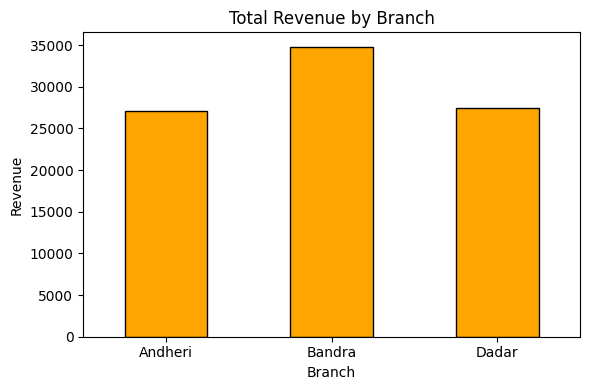

In [12]:
# Bar chart showing total revenue per branch
plt.figure(figsize = (6, 4))

branch_revenue.plot(kind = 'bar', color = 'orange', edgecolor = 'black')

plt.title('Total Revenue by Branch')

plt.xlabel('Branch')

plt.ylabel('Revenue')

plt.xticks(rotation = 0)

plt.tight_layout()

plt.savefig('2_Insights_Revenue_by_Branch.png')

plt.show()

#### `Step 10 :- Print Outputs`

In [13]:
print(f'\nBranch Revenue:\n{branch_revenue}')

print(f'\nCategory Average Revenue per Order:\n{category_average_revenue}')

print(f'\nOverall Average Order Value: {data_frame['Average_Order_Value'].mean().round(2)}')

print(f'\nBranch Order:\n{branch_orders}')

print(f'\nHighest Order Branch:\n{highest_branch}')


Branch Revenue:
Branch
Andheri    27150.0
Bandra     34800.0
Dadar      27500.0
Name: Revenue, dtype: float64

Category Average Revenue per Order:
Food_Category
Dessert        150.000000
Main Course    300.000000
Snacks         103.645833
Name: Average_Order_Value, dtype: float64

Overall Average Order Value: 197.05

Branch Order:
Branch
Andheri    113
Bandra     157
Dadar      198
Name: Orders, dtype: int64

Highest Order Branch:
Dadar


#### `Information`
> Rows: 12

> Columns: 6 (Date, Branch, Food_Category, Orders, Revenue, Avg_Order_Value)

> Missing Values: 1 (Revenue in Snacks, filled with median = 5500)

#### `Data Insights`
> Bandra generated the highest revenue (₹34,800).

> Main Course has the highest average order value (₹300).

> Overall average order value across all branches is (₹197.05).

> Dadar branch has the highest number of orders (198).

> Missing value in Snacks revenue was filled with median (₹5500).

#### `Business Insights`
> Bandra branch is most profitable in terms of revenue.

> Dadar branch has the highest customer traffic (orders).

> Main Course items are premium and generate maximum revenue per order.

> Snacks are lower value but steady sellers.

#### `Risks`
> Over‑dependence on Main Course for high revenue.

> Dadar branch may face operational strain due to high order volume.

> Missing or messy data can mislead decisions if not handled carefully.

#### `Opportunities`
> Upsell Main Course items in Dadar branch to maximize revenue.

> Improve marketing in Andheri to close the gap with Bandra.

> Introduce combo offers for Snacks to raise average order value.

#### `Recommendations`
> Ensure data quality checks to avoid missing values.

> Stock and staff more at Dadar branch to handle high traffic.

> Promote premium Main Course dishes in Bandra and Andheri.

> Create Snacks + Main Course bundles to increase per‑order spend.

#### `Expected Business Impact`
> Higher revenue from premium dishes.

> Better customer satisfaction at Dadar due to improved service.

> Increased profitability through bundles and upselling.

#### `Future Prediction`
> If Dadar’s traffic continues, it will remain the busiest branch.

> Bandra will likely stay top in revenue unless Dadar improves upselling.

> Main Course will remain the most profitable category.